In [7]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from quantumScarFunctions import *
from quantumScarsPlotting import *

[ 0.05835765 -0.03053808  0.04110535  0.01795327] [ 0.01733695  0.27819766  0.17503502 -0.06993509] [-0.10540677  0.1185375  -0.13008307  0.26886301]


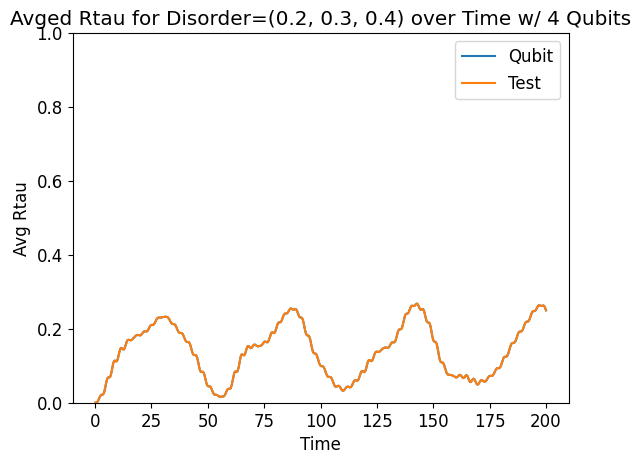

In [8]:
wd = 0.6366896896896898
wm = 1.0
tlist = np.linspace(0, 200, 500)
dz = 0.2
dy = 0.3
dx = 0.4
N = 4
reals = 1
amp = 0.1
args = {"A": amp, "omega": wd * 5.0}
qargs = {"A": amp, "omega": wm}

qubit_dR = []
qubit_dR_test = []

qH0_clean, qH1, qeigvals, qeigstates = get_qubit_ham(N, wm=wm)

for _ in range(reals):
    qH0, qeigvals, qeigstates = get_dis_qubit_ham(qH0_clean, N, ham_disorder=[dz, dy, dx], fixed_seed=True)
    qband = qeigvals[-1] - qeigvals[0]

    qH = qt.QobjEvo([qH0, [qH1, coeff]], args=qargs)
    qpsi_t = qt.sesolve(qH, qeigstates[0], tlist, e_ops=[qH0])

    qRtau = np.real(qpsi_t.expect[0] - qpsi_t.expect[0][0]) / qband
    qubit_dR.append(qRtau)

for _ in range(reals):
    qH0_list, qH1_list = get_qubit_ham_test(N, ham_disorder=[dz, dy, dx], fixed_seed=True)
    
    qbands = []
    qRtau_one_test = []
    for i in range(N):
        qH0 = qH0_list[i]
        qH1 = qH1_list[i]
        eigenvalues, eigenstates = qH0.eigenstates()
        qband = eigenvalues[-1] - eigenvalues[0]
        qbands.append(qband)

        qH = qt.QobjEvo([qH0, [qH1, coeff]], args=qargs)
        qpsi_t = qt.sesolve(qH, eigenstates[0], tlist, e_ops=[qH0])

        qRtau_test = np.real(qpsi_t.expect[0] - qpsi_t.expect[0][0])
        qRtau_one_test.append(qRtau_test)

    qRtau_one_test = np.sum(qRtau_one_test, axis=0) / np.sum(qbands)
    qubit_dR_test.append(qRtau_one_test)

qubit_dR = np.array(qubit_dR)
plotQubit = np.mean(qubit_dR, axis=0)

qubit_dR_test = np.array(qubit_dR_test)
plotQubit_test = np.mean(qubit_dR_test, axis=0)

plt.plot(tlist, plotQubit, label="Qubit")
plt.plot(tlist, plotQubit_test, label="Test")
plt.title(f"Avged Rtau for Disorder={dz, dy, dx} over Time w/ {N} Qubits")
plt.ylabel("Avg Rtau")
plt.xlabel("Time")
plt.ylim(0, 1)
plt.legend()
plt.show()

# plt.plot(tlist, plotScar[1:] / plotQubit[1:], label="Ratio")
# plt.show()